
Параметры модели линейной регрессии:

Наклон: 0.3303 ⋅ X₁, -0.0793 ⋅ X₂
Смещение: 5.4969
R² (коэффициент детерминации): 0.9983

----------------------------------------------

--- Миссия 1 ---
Длина маршрута XY: 1074.88 м
Длина маршрута XYZ: 1081.54 м
Рассчетное время преодоления маршрута: 274.7 c



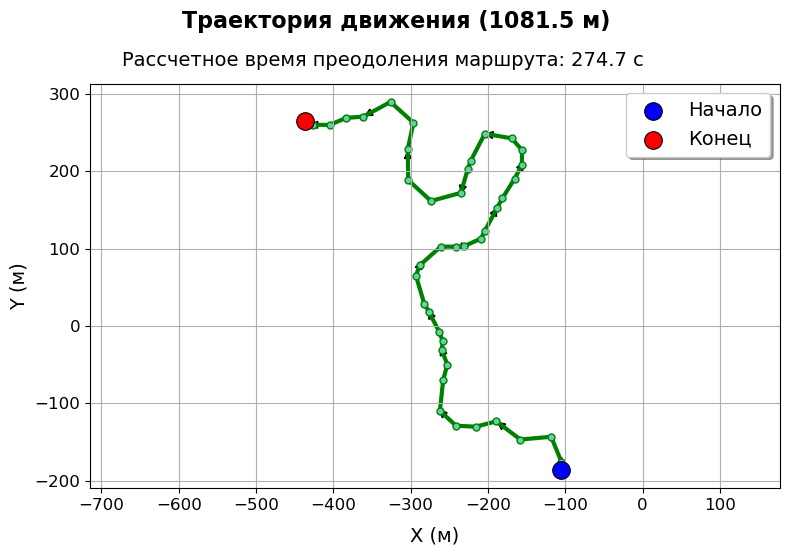


----------------------------------------------

--- Миссия 2 ---
Длина маршрута XY: 1236.14 м
Длина маршрута XYZ: 1244.89 м
Рассчетное время преодоления маршрута: 315.0 c



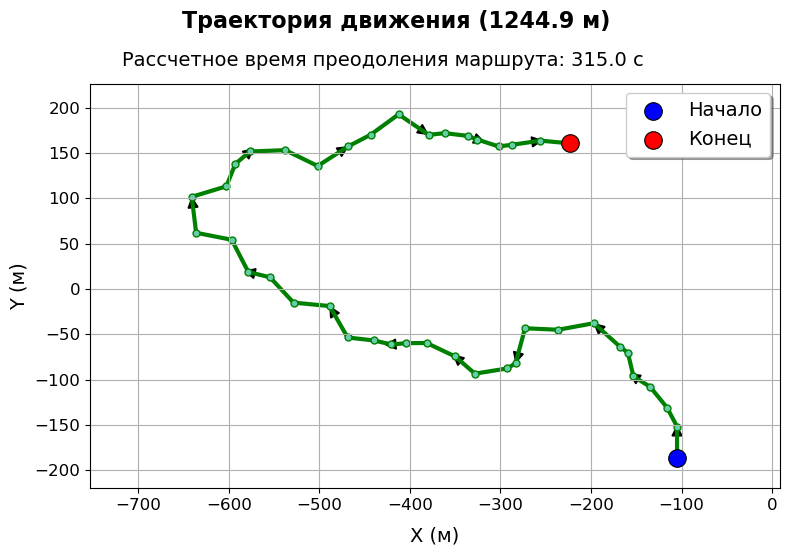


----------------------------------------------

--- Миссия 3 ---
Длина маршрута XY: 1192.82 м
Длина маршрута XYZ: 1200.97 м
Рассчетное время преодоления маршрута: 304.2 c



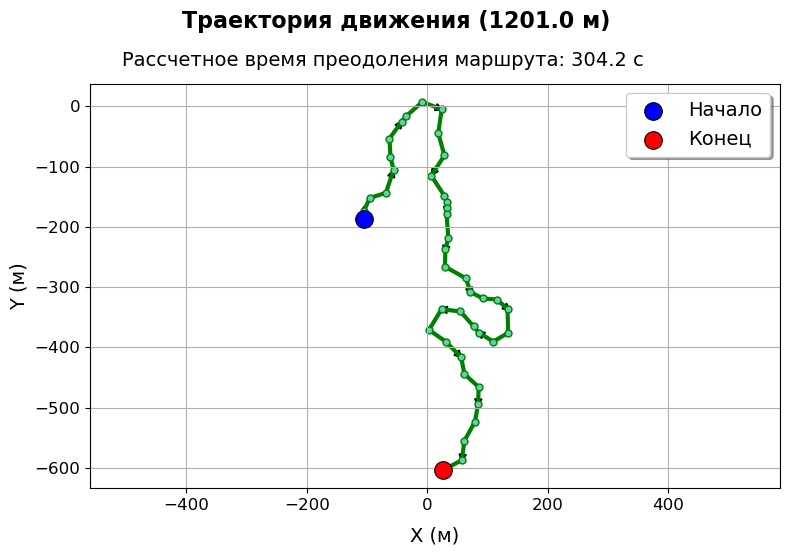


----------------------------------------------

--- Миссия 4 ---
Длина маршрута XY: 1101.16 м
Длина маршрута XYZ: 1104.89 м
Рассчетное время преодоления маршрута: 281.5 c



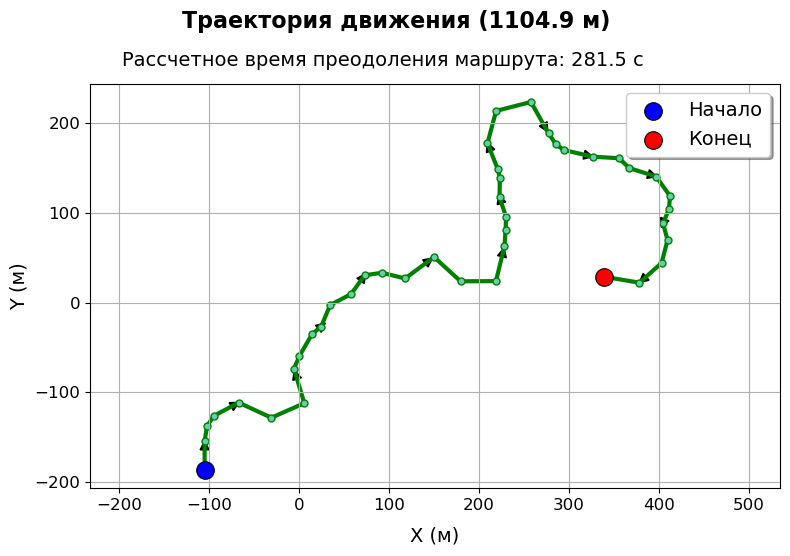


----------------------------------------------

--- Миссия 5 ---
Длина маршрута XY: 1270.59 м
Длина маршрута XYZ: 1279.64 м
Рассчетное время преодоления маршрута: 323.6 c



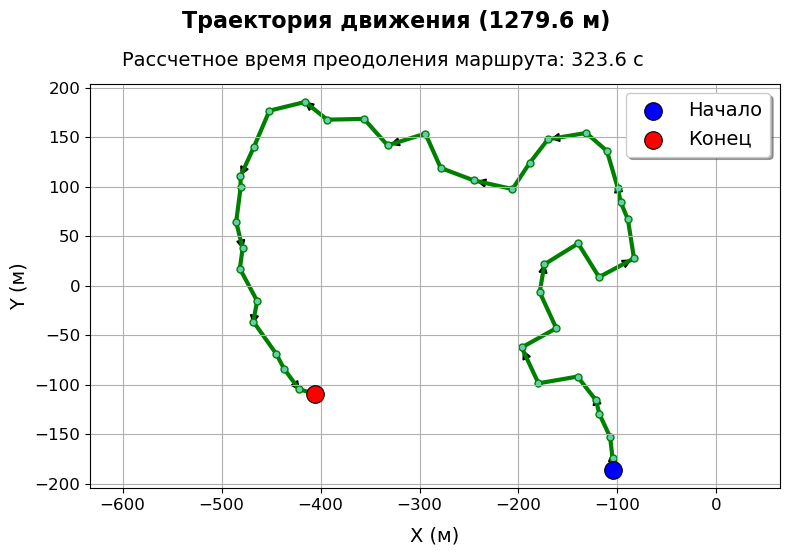


----------------------------------------------

--- Миссия 6 ---
Длина маршрута XY: 1073.37 м
Длина маршрута XYZ: 1082.57 м
Рассчетное время преодоления маршрута: 274.1 c



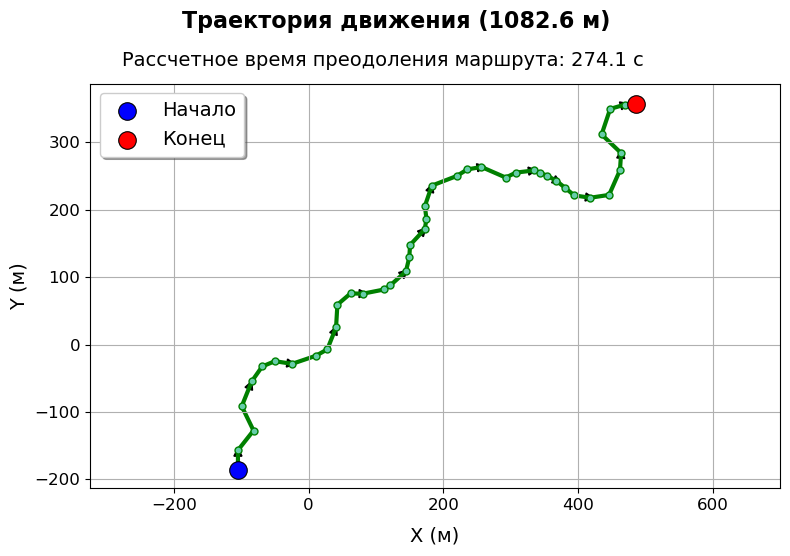


----------------------------------------------

--- Миссия 7 ---
Длина маршрута XY: 1134.28 м
Длина маршрута XYZ: 1141.20 м
Рассчетное время преодоления маршрута: 289.6 c



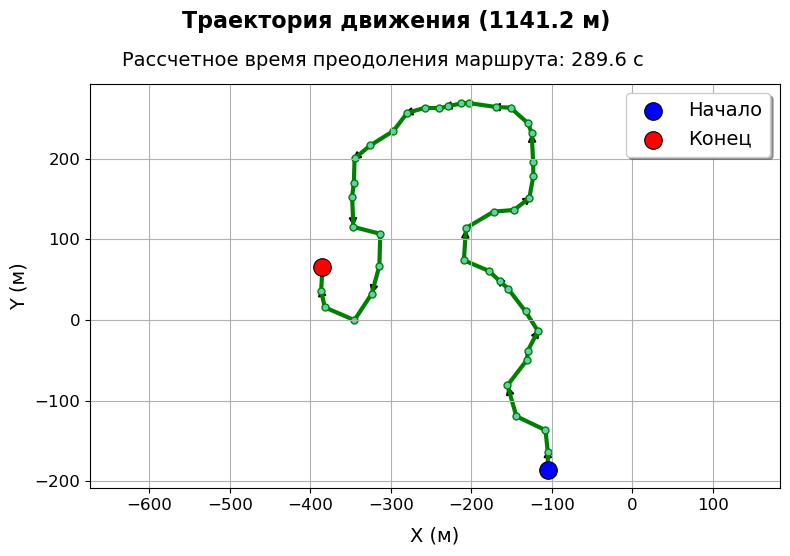


----------------------------------------------

--- Миссия 8 ---
Длина маршрута XY: 1278.78 м
Длина маршрута XYZ: 1285.38 м
Рассчетное время преодоления маршрута: 325.9 c



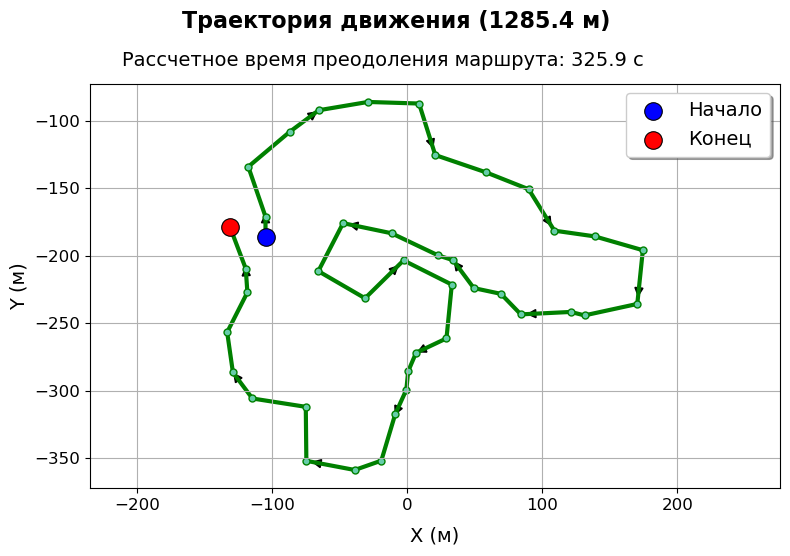


----------------------------------------------

--- Миссия 9 ---
Длина маршрута XY: 1162.26 м
Длина маршрута XYZ: 1171.52 м
Рассчетное время преодоления маршрута: 296.4 c



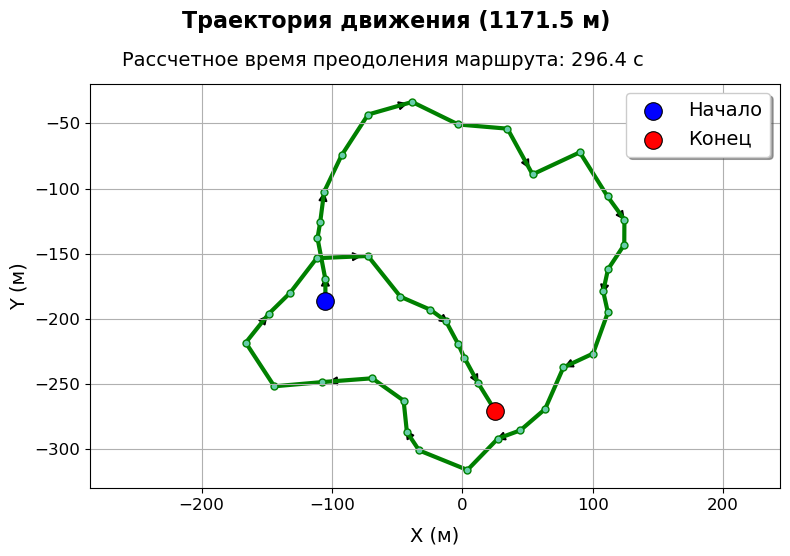


----------------------------------------------

--- Миссия 10 ---
Длина маршрута XY: 1219.03 м
Длина маршрута XYZ: 1228.75 м
Рассчетное время преодоления маршрута: 310.6 c



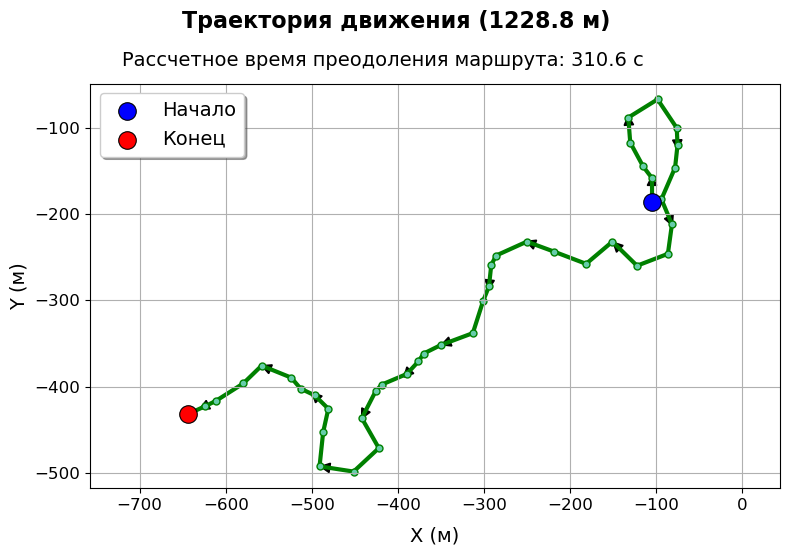

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from copy import deepcopy

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import json
import os


def trainLinearRegressionModel(print_information=True):
    # Данные для обучения (с ранее проведенных полётов)
    X = np.array([[890.67, 900.38], [915.6, 940.28], [1033.59, 1052.36], [1137.73, 1163.86], 
                  [1045.34, 1062.41], [1091.98, 1109.99], [1139.31, 1150.8], [1305.26, 1324.49]])
    y = np.array([228, 233, 262, 290, 265.5, 280.5, 291.5, 330])
    
    # Создание, обучение и прогноз модели
    model = LinearRegression()
    model.fit(X, y)

    if print_information:
        y_pred = model.predict(X)
        print(f"\nПараметры модели линейной регрессии:\n")
        print(f"Наклон: {model.coef_[0]:.4f} ⋅ X₁, {model.coef_[1]:.4f} ⋅ X₂")
        print(f"Смещение: {model.intercept_:.4f}")
        print(f"R² (коэффициент детерминации): {r2_score(y, y_pred):.4f}")
        
    return model


def metresToDegrees(X, Y, home=[55.7558, 37.6173, 0]):
    newX = [55.7541275]
    newY = [37.6156273]
    for x, y in zip(X[1:], Y[1:]):
        newX.append(round(home[0] + x * 8.9817436e-06, 10))
        newY.append(round(home[1] + y * 1.59271828e-05, 10))
        
    return newX, newY


def plotMission(x, y, flight_time, distance):
    fig = plt.figure(figsize=(8, 6))
    plt.grid()
    plt.plot(x, 
             y, 
             color='green',  
             marker='o', 
             mfc='mediumaquamarine', 
             mec='green', 
             linewidth=3, 
             ms=5, 
             zorder=1,
             linestyle='solid')
    
    plt.scatter(x[0], 
                y[0], 
                color='blue', 
                s=160, 
                edgecolor='black', 
                linewidth=0.8, 
                zorder=2,
                label='Начало')
    
    plt.scatter(x[-1], 
                y[-1], 
                color='red', 
                s=160, 
                edgecolor='black', 
                linewidth=0.8, 
                zorder=2,
                label='Конец')

    # Создание стрелок направления (динамическая коррекция размера)
    arrow_size = min(max(3 + (round(max(map(abs, [max(x) - min(x), max(y) - min(y)]))) - 130) // 50, 2), 20)  
    for i in range(0, 42, 3):
        plt.arrow(x[i], 
                  y[i], 
                  (x[i + 1] - x[i]) * 0.7, 
                  (y[i + 1] - y[i]) * 0.7, 
                  head_width=arrow_size, 
                  head_length=arrow_size, 
                  zorder=0,
                  fc='k', 
                  ec='k')
    
    
    plt.yticks(fontsize=12)
    plt.xticks(fontsize=12)

    plt.title(f'Траектория движения ({distance:.1f} м)          ', 
              fontweight='demibold', 
              fontsize=16, linespacing=1.5, pad=40)

    plt.suptitle(f'Рассчетное время преодоления маршрута: {flight_time:.1f} c    ', 
          fontweight='medium', 
          fontsize=14, linespacing=1.5, y=0.85)
    
    plt.xlabel('X (м)', 
               fontsize=14, 
               fontweight='medium', labelpad=10)
    
    plt.ylabel('Y (м)', 
               fontsize=14, 
               fontweight='medium')
    
    plt.legend(fontsize=14, 
               shadow=True, 
               loc='best')
    
    plt.axis('equal')
    plt.tight_layout()
    plt.savefig("mission.png", dpi=600, bbox_inches='tight')
    plt.show()


def printFlightInformation(distanceXY, distanceXYZ):
    print('\n', '-' * 46, sep='')
    print(f"\n--- Миссия {k+1} ---")
    print(f"Длина маршрута XY: {distanceXY:.2f} м")
    print(f"Длина маршрута XYZ: {distanceXYZ:.2f} м")

    pred = model.predict([[distanceXY, distanceXYZ]])
    print(f"Рассчетное время преодоления маршрута: {pred[0]:.1f} c\n")

    return pred[0], distanceXYZ


def writeMissionToFile(mission):
    with open('baseMission.plan', 'r', encoding='utf-8') as f:
        data = json.load(f)
    
    for i, item in enumerate(data['mission']['items']):
        item['params'][-3:] = [mission[k][j][i] for j in range(3)]
    
    with open(f'Missions\Mission_{k+1}.plan', 'w', encoding='utf-8') as f:
        json.dump(data, f, indent=4, ensure_ascii=False)


os.makedirs('Missions', exist_ok=True)

# Расстояние между точками (не рекомендуется ставить min_distance < 10)
min_distance = 10
max_distance = 40

# Количество миссий
n_missions = 10

# Начальная точка
x = [-105.022]
y = [-186.212]
z = [-15]

model = trainLinearRegressionModel()
mission_init = [[x, y, z] for _ in range(n_missions)]

for k in range(n_missions):
    mission = deepcopy(mission_init) 
    
    # Начальное направление 90° (прямо) и дистанция до первой точки 20 м
    current_angle = np.pi/2 
    distance = 20
    
    for i in range(0, 41):
        # Случайное изменение угла
        angle = np.pi/2 * distance / max_distance
        angle_change = np.random.uniform(-angle, angle)
        current_angle += 0 if i == 0 else angle_change
    
        # Случайное расстояние 
        b = abs(angle_change / (np.pi/2) * 3) if abs(angle_change) > np.pi/4 else 1
        distance = min(np.random.uniform(min_distance, max_distance) * b, max_distance)
        
        # Новая точка
        new_x_point = round(mission[k][0][-1] + distance * np.cos(current_angle), 3)
        new_y_point = round(mission[k][1][-1] + distance * np.sin(current_angle), 3)
        new_z_point = min(round(random.triangular(mission[k][2][-1] - distance / 3.5, mission[k][2][-1] + distance / 3.5), 3), -1)
        
        mission[k][0].append(new_x_point)
        mission[k][1].append(new_y_point)
        mission[k][2].append(new_z_point)
    
    # Рассчет длины маршрута
    distanceXY = sum(np.sqrt(np.diff(mission[k][0])**2 + np.diff(mission[k][1])**2))
    distanceXYZ = sum(np.sqrt(np.diff(mission[k][0])**2 + np.diff(mission[k][1])**2 + np.diff(mission[k][2])**2))

    # Вывод информации о миссии
    flight_time, distance = printFlightInformation(distanceXY, distanceXYZ)
    plotMission(mission[k][0], mission[k][1], flight_time, distance)

    # Преобразование координат, заданных в метрах, в широту и долготу
    mission[k][0], mission[k][1] = metresToDegrees(mission[k][1], mission[k][0])
    
    # Запись данных в файл
    writeMissionToFile(mission)
